# Rough Dimensionality Reduction with Python

Practical feature-removal techniques for rough dimensionality reduction.

- identify features with many missing values
- understand complete-case analysis 0
- remove low-variance features
- detect highly correlated features
- use target-aware checks to decide which feature to keep
- compare the dataset before and after reduction

## 1. Libraries and setup

The notebook uses common analytics libraries. `missingno` is optional; when it is not installed, the notebook continues with pandas and seaborn visualizations.

In [29]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from scipy import stats
import missingno as msno

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Simple toy dataset

This small dataset makes the logic visible:
- `middle_name_score` is mostly missing
- `country_code` and `constant_sensor` contain almost no variation
- `age` and `age_bracket_numeric` are strongly related
- `income` and `income_duplicate` are almost the same information

In [31]:
toy_df = pd.DataFrame({
    "customer_id": range(1, 13),
    "age": [22, 25, 27, 31, 35, 38, 42, 45, 48, 52, 57, 60],
    "age_bracket_numeric": [20, 20, 20, 30, 30, 30, 40, 40, 40, 50, 50, 60],
    "income": [35, 38, 40, 44, 50, 54, 59, 63, 67, 72, 78, 82],
    "income_duplicate": [35.2, 38.3, 40.4, 43.7, 50.5, 53.7, 59.4, 62.8, 67.3, 71.8, 77.5, 82.4],
    "country_code": ["DE"] * 12,
    "constant_sensor": [1] * 12,
    "middle_name_score": [np.nan, np.nan, np.nan, 1, np.nan, np.nan, np.nan, np.nan, 2, np.nan, np.nan, np.nan],
    "target_buy": [0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1],
})

toy_df

,customer_id,age,age_bracket_numeric,income,income_duplicate,country_code,constant_sensor,middle_name_score,target_buy
0,1,22,20,35,35.200,DE,1,NaN,0
1,2,25,20,38,38.300,DE,1,NaN,0
2,3,27,20,40,40.400,DE,1,NaN,0
3,4,31,30,44,43.700,DE,1,1.000,0
4,5,35,30,50,50.500,DE,1,NaN,1
5,6,38,30,54,53.700,DE,1,NaN,0
6,7,42,40,59,59.400,DE,1,NaN,1
7,8,45,40,63,62.800,DE,1,NaN,1
8,9,48,40,67,67.300,DE,1,2.000,1
9,10,52,50,72,71.800,DE,1,NaN,1


## 3. Method A — Missing-value based feature removal

**Idea.** A feature with too many missing values often contributes little reliable information.

**Implementation logic.**
1. Calculate missing percentage per row and per feature.
2. Visualize missingness.
3. Choose a threshold.
4. Remove features above the threshold.

Thresholds are analytical decisions. Start conservatively and make the threshold easy to change.

,missing_percent,missing_count
middle_name_score,83.333,10
age,0.000,0
age_bracket_numeric,0.000,0
country_code,0.000,0
constant_sensor,0.000,0
customer_id,0.000,0
income,0.000,0
income_duplicate,0.000,0
target_buy,0.000,0


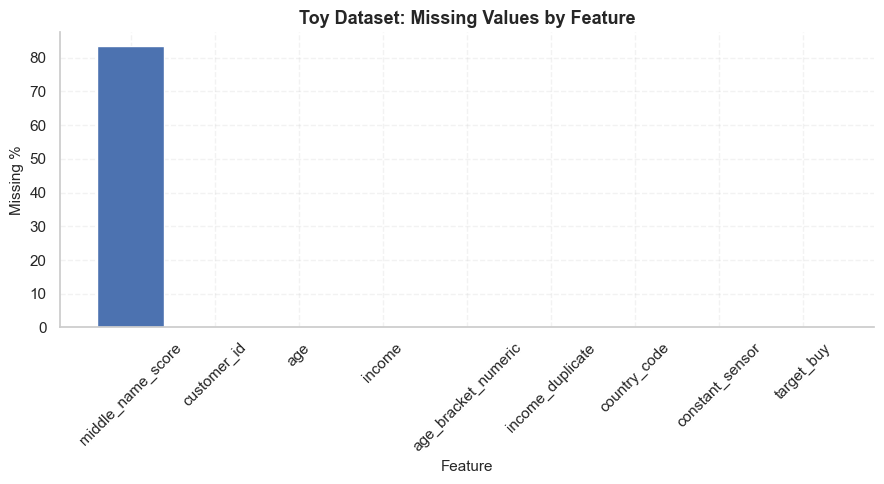

In [33]:
# Missingness diagnostics: percent missing per feature (for column filtering) and per row (for row screening).
missing_by_column = toy_df.isna().mean().mul(100).sort_values(ascending=False)
missing_by_row = toy_df.isna().mean(axis=1).mul(100)

display(pd.DataFrame({
    "missing_percent": missing_by_column,
    "missing_count": toy_df.isna().sum()
}).sort_values("missing_percent", ascending=False))

fig, ax = plt.subplots()
ax.bar(missing_by_column.index.astype(str), missing_by_column.values)
ax.set_title("Toy Dataset: Missing Values by Feature")
ax.set_ylabel("Missing %")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

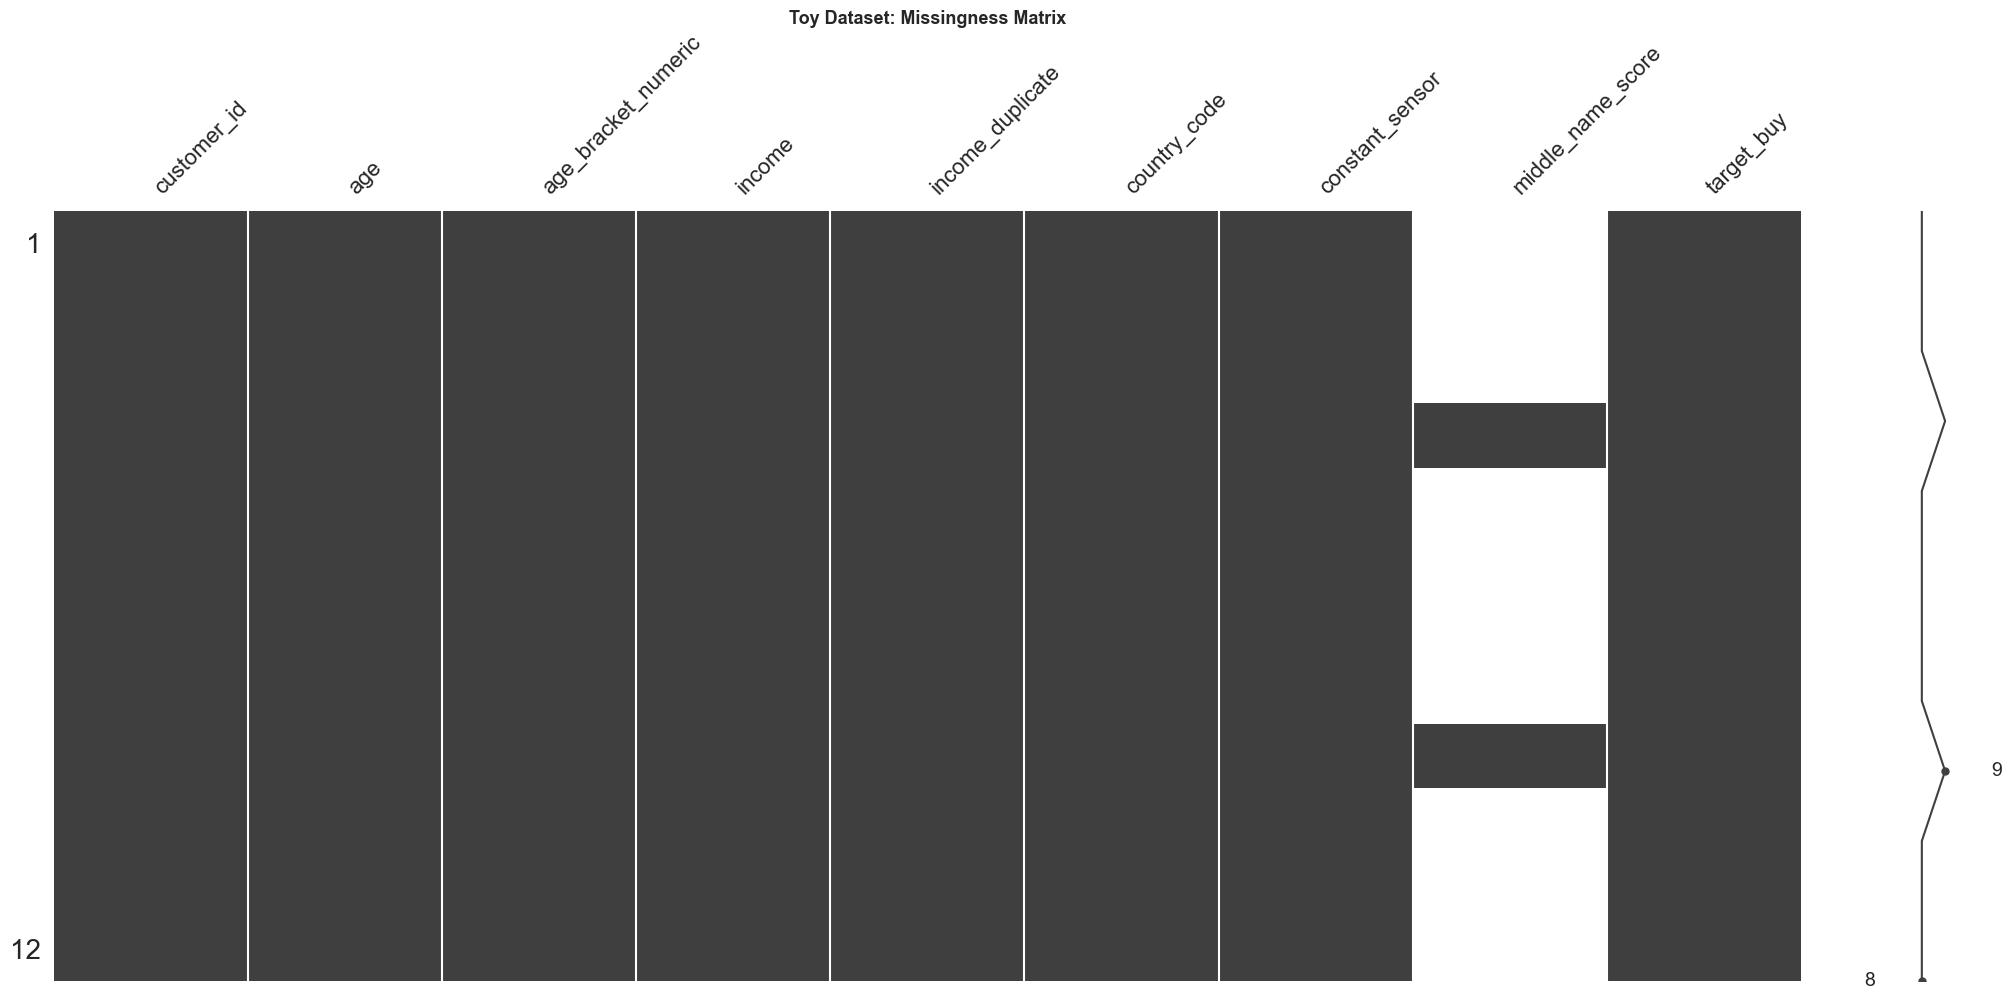

In [34]:
# Optional missingness matrix: useful to see whether missing values follow a pattern.
msno.matrix(toy_df)
plt.title("Toy Dataset: Missingness Matrix")
plt.show()

In [35]:
MISSING_THRESHOLD = 60  # remove features with more than 60% missing values

features_to_drop_missing = missing_by_column[missing_by_column > MISSING_THRESHOLD].index.tolist()
toy_after_missing = toy_df.drop(columns=features_to_drop_missing)

print("Missing-value threshold:", MISSING_THRESHOLD, "%")
print("Features removed:", features_to_drop_missing)
print("Shape before:", toy_df.shape)
print("Shape after:", toy_after_missing.shape)

toy_after_missing.head()

Missing-value threshold: 60 %
Features removed: ['middle_name_score']
Shape before: (12, 9)
Shape after: (12, 8)


,customer_id,age,age_bracket_numeric,income,income_duplicate,country_code,constant_sensor,target_buy
0,1,22,20,35,35.200,DE,1,0
1,2,25,20,38,38.300,DE,1,0
2,3,27,20,40,40.400,DE,1,0
3,4,31,30,44,43.700,DE,1,0
4,5,35,30,50,50.500,DE,1,1


### Interpretation

`middle_name_score` is removed because it is mostly missing. This is safer than applying a complex imputation method to a feature that contains very little observed information.

Important distinction:
- column removal reduces features
- row removal reduces cases

For modeling, aggressive row removal can quickly destroy the training dataset.

## 4. Complete-case analysis: useful concept, risky default

Complete-case analysis keeps only rows with no missing values.

It is simple, but it can remove many useful records because one missing cell is enough to remove the whole row.

In [36]:
complete_case_df = toy_df.dropna()

print("Rows before complete-case analysis:", len(toy_df))
print("Rows after complete-case analysis:", len(complete_case_df))
print("Rows removed:", len(toy_df) - len(complete_case_df))
print("Percentage of rows removed:", round((1 - len(complete_case_df) / len(toy_df)) * 100, 1), "%")

complete_case_df

Rows before complete-case analysis: 12
Rows after complete-case analysis: 2
Rows removed: 10
Percentage of rows removed: 83.3 %


,customer_id,age,age_bracket_numeric,income,income_duplicate,country_code,constant_sensor,middle_name_score,target_buy
3,4,31,30,44,43.700,DE,1,1.000,0
8,9,48,40,67,67.300,DE,1,2.000,1


### Interpretation

Complete-case analysis is rarely a good first choice for sensor or operational datasets. A row may still contain valuable information even if one feature is missing.

A practical approach is:
- remove rows only when almost everything is missing
- remove columns when a feature is mostly missing
- consider imputation later for useful features with moderate missingness

In [37]:
ROW_MISSING_THRESHOLD = 80  # remove rows only if more than 80% of values are missing

rows_to_keep = toy_df.isna().mean(axis=1).mul(100) <= ROW_MISSING_THRESHOLD
toy_after_row_screen = toy_df.loc[rows_to_keep].copy()

print("Rows removed by conservative row screening:", (~rows_to_keep).sum())
print("Shape after conservative row screening:", toy_after_row_screen.shape)

Rows removed by conservative row screening: 0
Shape after conservative row screening: (12, 9)


## 5. Method B — Low-variance feature removal

**Idea.** A feature with almost no variation usually adds little value to a model.

Typical examples:
- a country column where all records are from the same country
- a sensor that always reports the same value
- a binary flag that is almost always zero

Important pitfall: variance depends on scale. A feature measured in euros may naturally have larger variance than a feature measured as a percentage.

,variance,standard_deviation,unique_values
constant_sensor,0.000,0.000,1
age,159.424,12.626,12
age_bracket_numeric,171.970,13.114,5
income_duplicate,250.943,15.841,12
income,253.788,15.931,12


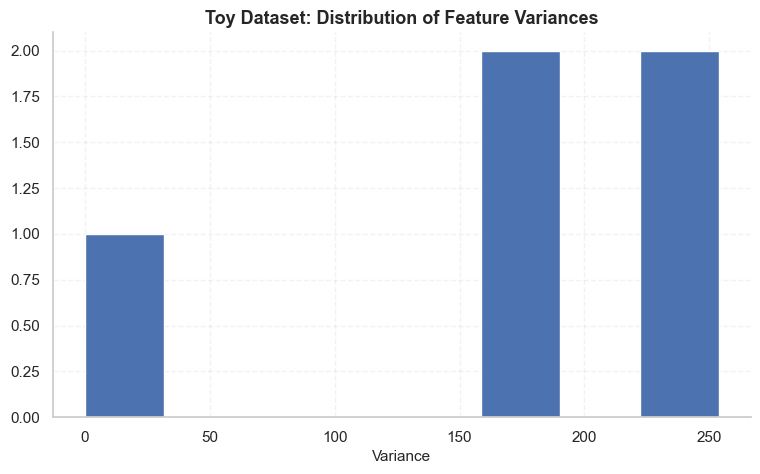

In [38]:
numeric_toy = toy_after_missing.select_dtypes(include="number").drop(columns=["customer_id", "target_buy"], errors="ignore")

variance_table = pd.DataFrame({
    "variance": numeric_toy.var(),
    "standard_deviation": numeric_toy.std(),
    "unique_values": numeric_toy.nunique()
}).sort_values("variance")

display(variance_table)

fig, ax = plt.subplots()
ax.hist(variance_table["variance"].dropna(), bins=8)
ax.set_title("Toy Dataset: Distribution of Feature Variances")
ax.set_xlabel("Variance")
plt.show()

In [39]:
VARIANCE_THRESHOLD = 0.01

features_to_drop_low_variance = variance_table[variance_table["variance"] <= VARIANCE_THRESHOLD].index.tolist()
toy_after_variance = toy_after_missing.drop(columns=features_to_drop_low_variance)

print("Variance threshold:", VARIANCE_THRESHOLD)
print("Features removed:", features_to_drop_low_variance)
print("Shape before:", toy_after_missing.shape)
print("Shape after:", toy_after_variance.shape)

Variance threshold: 0.01
Features removed: ['constant_sensor']
Shape before: (12, 8)
Shape after: (12, 7)


### Scaling check for variance

When numeric features are on different scales, compare variance after scaling as a diagnostic. This does not automatically tell you what to remove, but it helps avoid scale-driven decisions.

,original_variance,minmax_scaled_variance
constant_sensor,0.000,0.000
age,159.424,0.110
age_bracket_numeric,171.970,0.107
income_duplicate,250.943,0.113
income,253.788,0.115


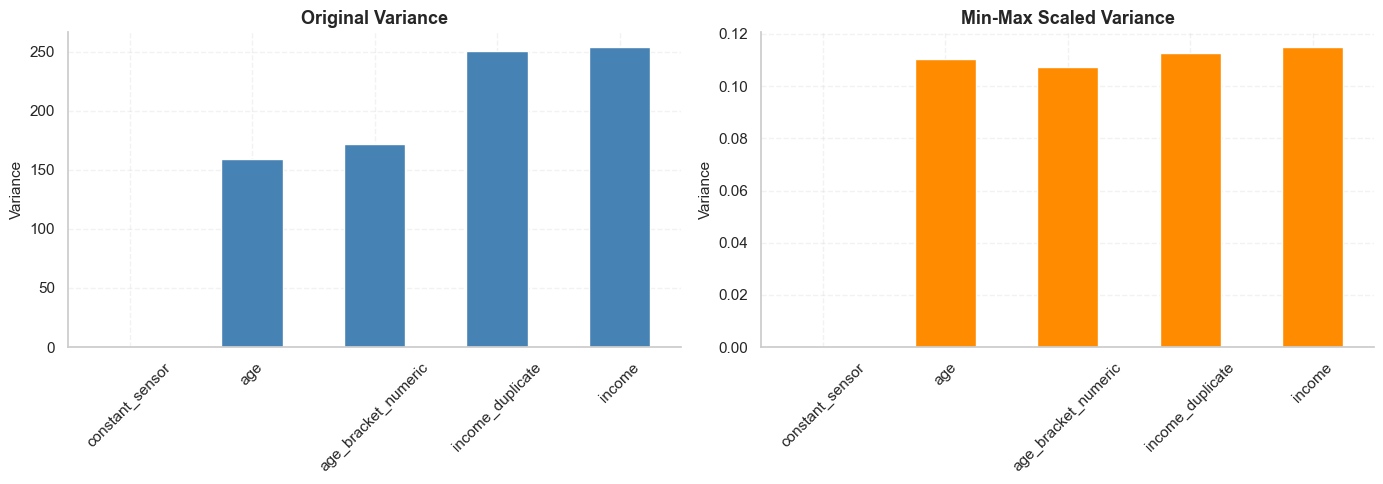

In [42]:
scaled_numeric = pd.DataFrame(
    MinMaxScaler().fit_transform(numeric_toy),
    columns=numeric_toy.columns,
    index=numeric_toy.index
)

scaled_variance_table = pd.DataFrame({
    "original_variance": numeric_toy.var(),
    "minmax_scaled_variance": scaled_numeric.var()
}).sort_values("original_variance")

display(scaled_variance_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scaled_variance_table["original_variance"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Original Variance")
axes[0].set_ylabel("Variance")
axes[0].tick_params(axis="x", rotation=45)

scaled_variance_table["minmax_scaled_variance"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Min-Max Scaled Variance")
axes[1].set_ylabel("Variance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Low-variance removal is most reliable for constant or near-constant features.

Use caution when comparing variables with different measurement units. A low raw variance does not always mean low predictive value.

## 6. Method C — Correlation-based feature removal

**Idea.** Highly correlated features may carry redundant information.

The typical workflow:
1. compute a correlation matrix for numeric variables
2. inspect highly correlated pairs
3. remove only one feature from each pair
4. use domain knowledge or target relationship to decide which one to keep

Correlation is not causality. A high correlation can be meaningful, redundant, or completely spurious.

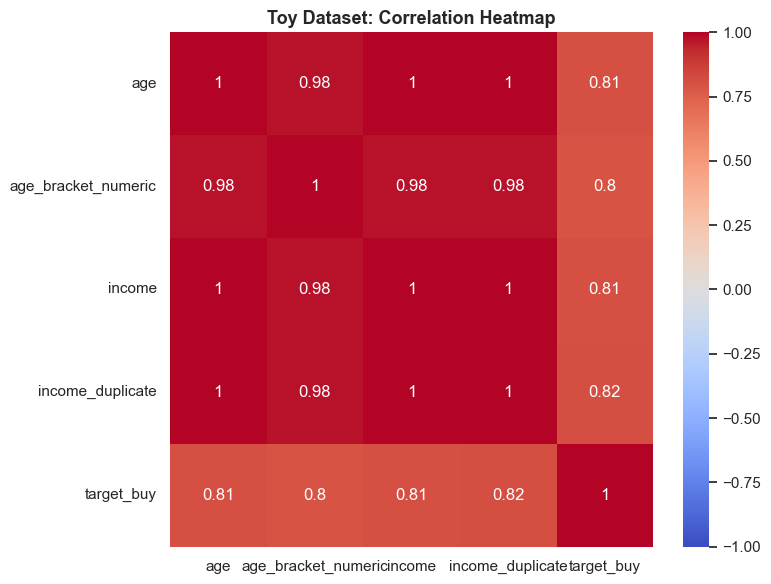

In [43]:
numeric_for_corr = toy_after_variance.select_dtypes(include="number").drop(columns=["customer_id"], errors="ignore")
corr = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Toy Dataset: Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
# Correlation cutoff used to flag potentially redundant feature pairs.
# Any absolute correlation at or above this value is considered "high".
CORRELATION_THRESHOLD = 0.95

# Build a feature-only numeric table for pairwise correlation checks.
corr_features = numeric_for_corr.drop(columns=["target_buy"], errors="ignore")

# Compute absolute Pearson correlations between all feature pairs.
abs_corr = corr_features.corr().abs()

# Keep only the upper triangle of the correlation matrix (excluding diagonal),
upper_triangle = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

# Convert the upper-triangle matrix into a tidy table of high-correlation pairs:
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
    .query("abs_correlation >= @CORRELATION_THRESHOLD")
    .sort_values("abs_correlation", ascending=False)
)

# Display candidate redundant feature pairs for the next target-aware keep/drop decision.
high_corr_pairs

,feature_1,feature_2,abs_correlation
11,income,income_duplicate,1.000
2,age,income,0.999
3,age,income_duplicate,0.999
1,age,age_bracket_numeric,0.976
7,age_bracket_numeric,income_duplicate,0.976
6,age_bracket_numeric,income,0.975


### Target-aware decision rule

When two features are highly correlated, a simple rule is to keep the one that has a stronger relationship with the target.

This is not a perfect rule, but it is more practical than dropping a feature blindly.

In [46]:
target = toy_after_variance["target_buy"]

target_corr = (
    toy_after_variance
    .select_dtypes(include="number")
    .corr(numeric_only=True)["target_buy"]
    .drop("target_buy")
    .abs()
    .sort_values(ascending=False)
)

display(pd.DataFrame({"abs_correlation_with_target": target_corr}))

features_to_drop_corr = []

for _, row in high_corr_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    f1_target_corr = target_corr.get(f1, 0)
    f2_target_corr = target_corr.get(f2, 0)

    feature_to_drop = f1 if f1_target_corr < f2_target_corr else f2
    features_to_drop_corr.append(feature_to_drop)

features_to_drop_corr = sorted(set(features_to_drop_corr))

toy_reduced = toy_after_variance.drop(columns=features_to_drop_corr)

print("Correlation threshold:", CORRELATION_THRESHOLD)
print("Features removed:", features_to_drop_corr)
print("Shape before:", toy_after_variance.shape)
print("Shape after:", toy_reduced.shape)

toy_reduced.head()

,abs_correlation_with_target
income_duplicate,0.817
income,0.811
age,0.809
customer_id,0.808
age_bracket_numeric,0.797


Correlation threshold: 0.95
Features removed: ['age', 'age_bracket_numeric', 'income']
Shape before: (12, 7)
Shape after: (12, 4)


,customer_id,income_duplicate,country_code,target_buy
0,1,35.200,DE,0
1,2,38.300,DE,0
2,3,40.400,DE,0
3,4,43.700,DE,0
4,5,50.500,DE,1


### Interpretation

Correlation filtering should not be fully automatic.

Before removing a feature, ask:
- Are the two variables measuring the same business concept?
- Is one variable more reliable?
- Is one easier to collect or maintain?
- Is one more strongly related to the target?
- Could the correlation be spurious?

## 7. Optional target relationship check with ANOVA-style feature scoring

For classification problems, numeric features can be compared across target groups.

This is not a replacement for the three rough feature-removal methods. It is an additional check to avoid removing a feature that looks weak on its own but separates target groups well.

In [47]:
anova_rows = []

for col in numeric_toy.columns:
    groups = [
        toy_df.loc[toy_df["target_buy"] == group, col].dropna()
        for group in sorted(toy_df["target_buy"].dropna().unique())
        if col in toy_df.columns
    ]

    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_value = stats.f_oneway(*groups)
        anova_rows.append({
            "feature": col,
            "f_statistic": f_stat,
            "p_value": p_value
        })

anova_table = pd.DataFrame(anova_rows).sort_values("p_value")
anova_table

,feature,f_statistic,p_value
3,income_duplicate,20.034,0.001
2,income,19.195,0.001
0,age,18.895,0.001
1,age_bracket_numeric,17.359,0.002
4,constant_sensor,NaN,NaN


### Interpretation

A small p-value suggests that the feature values differ across target groups. In business terms, the feature may help distinguish outcomes.

Use this as a supporting signal, not as a mechanical deletion rule.

## 8. Realistic example: Wine dataset with injected data-quality issues

The next example uses a built-in dataset and adds common issues found in operational datasets:
- missing values
- duplicated/correlated features
- low-variance columns
- scale differences
- target variable for model comparison

In [48]:
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()
wine_df = wine_df.rename(columns={"target": "wine_class"})

rng = np.random.default_rng(RANDOM_STATE)

# Add artificial data-quality issues for the walkthrough.
realistic_df = wine_df.copy()

# Mostly missing feature.
realistic_df["legacy_lab_measurement"] = rng.normal(100, 15, size=len(realistic_df))
realistic_df.loc[rng.random(len(realistic_df)) < 0.72, "legacy_lab_measurement"] = np.nan

# Moderate missingness in useful columns.
for col, missing_rate in {"magnesium": 0.10, "proline": 0.08, "alcohol": 0.05}.items():
    realistic_df.loc[rng.random(len(realistic_df)) < missing_rate, col] = np.nan

# Low-variance columns.
realistic_df["country_code_numeric"] = 1
realistic_df["near_constant_flag"] = rng.choice([0, 1], size=len(realistic_df), p=[0.97, 0.03])

# Strongly correlated duplicates.
realistic_df["alcohol_backup"] = realistic_df["alcohol"] * 1.01 + rng.normal(0, 0.02, size=len(realistic_df))
realistic_df["proline_scaled"] = realistic_df["proline"] * 0.001 + rng.normal(0, 0.01, size=len(realistic_df))

print("Original realistic shape:", realistic_df.shape)
realistic_df.head()

Original realistic shape: (178, 19)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class,legacy_lab_measurement,country_code_numeric,near_constant_flag,alcohol_backup,proline_scaled
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,"1,065.000",0,104.571,1,0,14.392,1.038
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,"1,050.000",0,NaN,1,0,13.321,1.036
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,"1,185.000",0,NaN,1,0,13.308,1.167
3,14.370,1.950,2.500,16.800,113.000,3.850,3.490,0.240,2.180,7.800,0.860,3.450,"1,480.000",0,114.108,1,0,14.527,1.458
4,13.240,2.590,2.870,21.000,NaN,2.800,2.690,0.390,1.820,4.320,1.040,2.930,735.000,0,NaN,1,0,13.353,0.723


## 9. Build reusable summary tables

These compact tables make it easier to choose thresholds and explain the decision.

In [49]:
TARGET_COLUMN = "wine_class"
ID_COLUMNS = []

def summarize_missingness(df):
    return (
        pd.DataFrame({
            "missing_count": df.isna().sum(),
            "missing_percent": df.isna().mean().mul(100),
            "dtype": df.dtypes.astype(str),
            "unique_values": df.nunique(dropna=True),
        })
        .sort_values("missing_percent", ascending=False)
    )

def summarize_variance(df, target_column=None, id_columns=None):
    id_columns = id_columns or []
    drop_cols = [c for c in [target_column, *id_columns] if c in df.columns]
    numeric_df = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

    return (
        pd.DataFrame({
            "variance": numeric_df.var(),
            "standard_deviation": numeric_df.std(),
            "missing_percent": numeric_df.isna().mean().mul(100),
            "unique_values": numeric_df.nunique(dropna=True),
        })
        .sort_values("variance")
    )

missing_summary = summarize_missingness(realistic_df)
variance_summary = summarize_variance(realistic_df, target_column=TARGET_COLUMN, id_columns=ID_COLUMNS)

display(missing_summary.head(10))
display(variance_summary.head(10))

,missing_count,missing_percent,dtype,unique_values
legacy_lab_measurement,127,71.348,float64,51
magnesium,17,9.551,float64,50
alcohol,16,8.989,float64,118
alcohol_backup,16,8.989,float64,162
proline_scaled,12,6.742,float64,166
proline,12,6.742,float64,115
malic_acid,0,0.000,float64,133
ash,0,0.000,float64,79
alcalinity_of_ash,0,0.000,float64,63
total_phenols,0,0.000,float64,97


,variance,standard_deviation,missing_percent,unique_values
country_code_numeric,0.000,0.000,0.000,1
nonflavanoid_phenols,0.015,0.124,0.000,39
near_constant_flag,0.033,0.181,0.000,2
hue,0.052,0.229,0.000,78
ash,0.075,0.274,0.000,79
proline_scaled,0.098,0.314,6.742,166
proanthocyanins,0.328,0.572,0.000,101
total_phenols,0.392,0.626,0.000,97
od280/od315_of_diluted_wines,0.504,0.710,0.000,122
alcohol,0.657,0.811,8.989,118


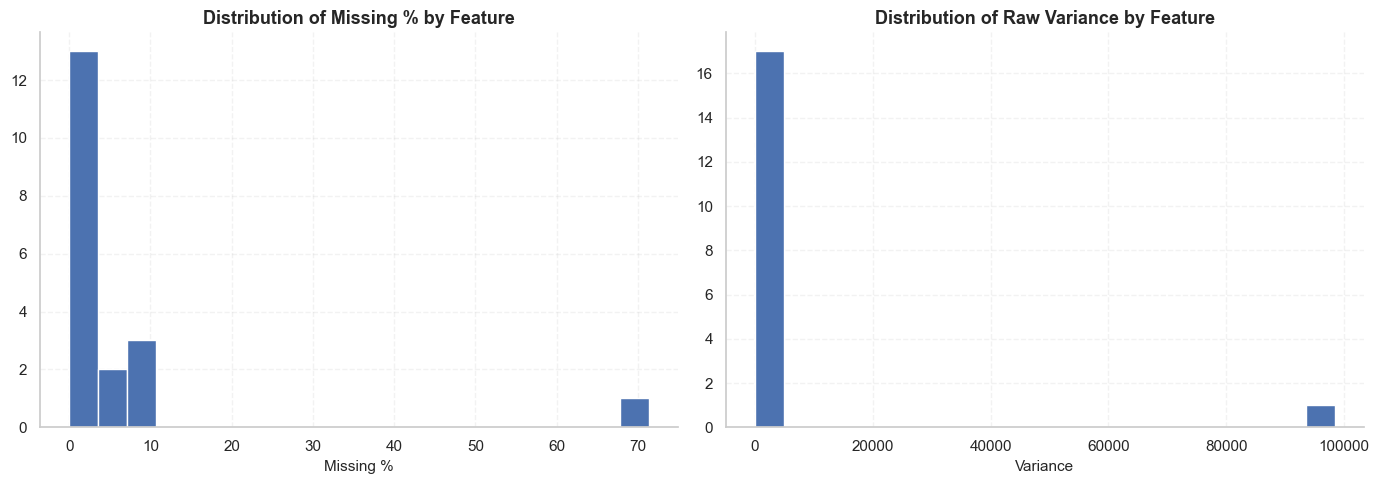

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(missing_summary["missing_percent"].dropna(), bins=20)
axes[0].set_title("Distribution of Missing % by Feature")
axes[0].set_xlabel("Missing %")

axes[1].hist(variance_summary["variance"].dropna(), bins=20)
axes[1].set_title("Distribution of Raw Variance by Feature")
axes[1].set_xlabel("Variance")

plt.tight_layout()
plt.show()

## 10. Apply missing-value threshold

The threshold is intentionally stored in one variable so it can be changed easily.

In [51]:
missing_threshold = 60

features_to_drop_missing_realistic = (
    missing_summary
    .query("missing_percent > @missing_threshold")
    .index
    .tolist()
)

df_step_1 = realistic_df.drop(columns=features_to_drop_missing_realistic)

print("Missing-value threshold:", missing_threshold, "%")
print("Features removed:", features_to_drop_missing_realistic)
print("Shape before:", realistic_df.shape)
print("Shape after:", df_step_1.shape)

Missing-value threshold: 60 %
Features removed: ['legacy_lab_measurement']
Shape before: (178, 19)
Shape after: (178, 18)


### Interpretation

A feature with more than 60% missing values is difficult to use reliably unless there is a strong business reason to keep it.

For rough dimensionality reduction, it is often reasonable to remove such features early and keep moderate missingness for later imputation.

## 11. Apply low-variance threshold

Use this step mainly to identify constant and near-constant features.

In [52]:
variance_summary_step_1 = summarize_variance(df_step_1, target_column=TARGET_COLUMN)

display(variance_summary_step_1.head(10))

low_variance_threshold = 0.001

features_to_drop_variance_realistic = (
    variance_summary_step_1
    .query("variance <= @low_variance_threshold")
    .index
    .tolist()
)

df_step_2 = df_step_1.drop(columns=features_to_drop_variance_realistic)

print("Low-variance threshold:", low_variance_threshold)
print("Features removed:", features_to_drop_variance_realistic)
print("Shape before:", df_step_1.shape)
print("Shape after:", df_step_2.shape)

,variance,standard_deviation,missing_percent,unique_values
country_code_numeric,0.000,0.000,0.000,1
nonflavanoid_phenols,0.015,0.124,0.000,39
near_constant_flag,0.033,0.181,0.000,2
hue,0.052,0.229,0.000,78
ash,0.075,0.274,0.000,79
proline_scaled,0.098,0.314,6.742,166
proanthocyanins,0.328,0.572,0.000,101
total_phenols,0.392,0.626,0.000,97
od280/od315_of_diluted_wines,0.504,0.710,0.000,122
alcohol,0.657,0.811,8.989,118


Low-variance threshold: 0.001
Features removed: ['country_code_numeric']
Shape before: (178, 18)
Shape after: (178, 17)


,raw_variance,minmax_scaled_variance
country_code_numeric,0.000,0.000
ash,0.075,0.022
alcalinity_of_ash,11.153,0.030
proanthocyanins,0.328,0.033
near_constant_flag,0.033,0.033
hue,0.052,0.035
color_intensity,5.374,0.039
magnesium,149.863,0.040
alcohol,0.598,0.041
alcohol_backup,0.611,0.042


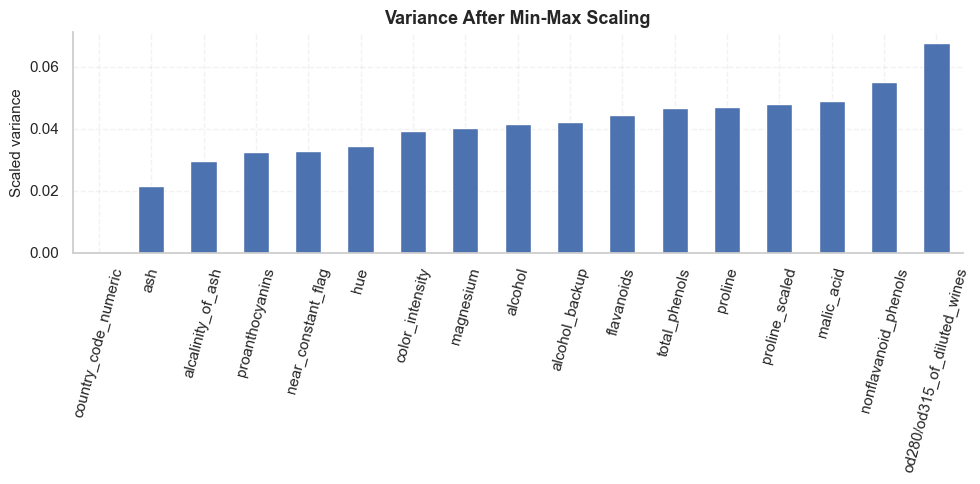

In [53]:
# Scaling diagnostic: helpful when variance is affected by units.
numeric_for_scaling = (
    df_step_1
    .drop(columns=[TARGET_COLUMN], errors="ignore")
    .select_dtypes(include="number")
)

# Simple median fill only for this scaling diagnostic.
numeric_for_scaling_filled = numeric_for_scaling.fillna(numeric_for_scaling.median())

minmax_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(numeric_for_scaling_filled),
    columns=numeric_for_scaling_filled.columns,
    index=numeric_for_scaling_filled.index
)

scaled_variance = (
    pd.DataFrame({
        "raw_variance": numeric_for_scaling_filled.var(),
        "minmax_scaled_variance": minmax_scaled.var()
    })
    .sort_values("minmax_scaled_variance")
)

display(scaled_variance.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
scaled_variance["minmax_scaled_variance"].plot(kind="bar", ax=ax)
ax.set_title("Variance After Min-Max Scaling")
ax.set_ylabel("Scaled variance")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

### Interpretation

The scaled variance view is a diagnostic, not a final answer. It helps identify features that looked important only because of their unit scale.

For rough feature removal, remove obvious low-information features first. Keep borderline features until model evaluation provides evidence.

## 12. Apply correlation filtering

This section identifies highly correlated numeric feature pairs and removes one feature from each pair.

The decision rule used here:
- calculate each feature’s absolute correlation with the target
- for each highly correlated pair, drop the feature with weaker target relationship
- keep the logic transparent and review the result manually

In [54]:
def find_high_correlation_pairs(df, target_column=None, threshold=0.90):
    numeric_df = df.drop(columns=[target_column], errors="ignore").select_dtypes(include="number")
    corr_matrix = numeric_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = (
        upper
        .stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
        .query("abs_correlation >= @threshold")
        .sort_values("abs_correlation", ascending=False)
        .reset_index(drop=True)
    )
    return pairs, corr_matrix

correlation_threshold = 0.90

high_corr_pairs_realistic, corr_matrix_realistic = find_high_correlation_pairs(
    df_step_2,
    target_column=TARGET_COLUMN,
    threshold=correlation_threshold
)

high_corr_pairs_realistic

,feature_1,feature_2,abs_correlation
0,alcohol,alcohol_backup,1.000
1,proline,proline_scaled,0.999


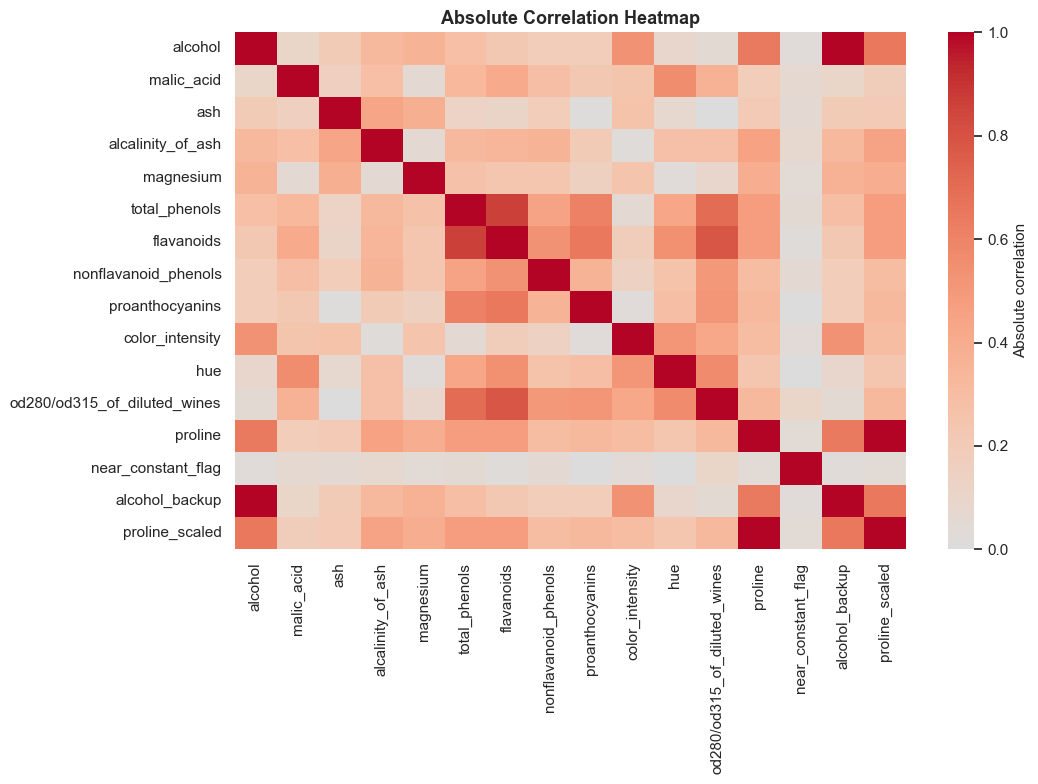

In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix_realistic,
    cmap="coolwarm",
    center=0,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Absolute correlation"}
)
ax.set_title("Absolute Correlation Heatmap")
plt.tight_layout()
plt.show()

In [55]:
def select_correlated_features_to_drop(df, high_corr_pairs, target_column):
    target_corr = (
        df
        .select_dtypes(include="number")
        .corr(numeric_only=True)[target_column]
        .drop(target_column)
        .abs()
        .sort_values(ascending=False)
    )

    decisions = []
    for _, row in high_corr_pairs.iterrows():
        f1 = row["feature_1"]
        f2 = row["feature_2"]
        f1_target_corr = target_corr.get(f1, 0)
        f2_target_corr = target_corr.get(f2, 0)
        drop_feature = f1 if f1_target_corr < f2_target_corr else f2

        decisions.append({
            "feature_1": f1,
            "feature_2": f2,
            "abs_correlation_between_features": row["abs_correlation"],
            "feature_1_abs_target_corr": f1_target_corr,
            "feature_2_abs_target_corr": f2_target_corr,
            "recommended_drop": drop_feature
        })

    return pd.DataFrame(decisions)

correlation_decisions = select_correlated_features_to_drop(
    df_step_2,
    high_corr_pairs_realistic,
    TARGET_COLUMN
)

display(correlation_decisions)

features_to_drop_corr_realistic = sorted(correlation_decisions["recommended_drop"].unique().tolist())
df_step_3 = df_step_2.drop(columns=features_to_drop_corr_realistic)

print("Correlation threshold:", correlation_threshold)
print("Features removed:", features_to_drop_corr_realistic)
print("Shape before:", df_step_2.shape)
print("Shape after:", df_step_3.shape)

,feature_1,feature_2,abs_correlation_between_features,feature_1_abs_target_corr,feature_2_abs_target_corr,recommended_drop
0,alcohol,alcohol_backup,1.000,0.318,0.318,alcohol
1,proline,proline_scaled,0.999,0.629,0.629,proline_scaled


Correlation threshold: 0.9
Features removed: ['alcohol', 'proline_scaled']
Shape before: (178, 17)
Shape after: (178, 15)


### Interpretation

The correlation filter removed redundant versions of existing variables. This makes the dataset smaller without necessarily losing much information.

However, this rule can fail when:
- the target relationship is unstable
- the correlation is spurious
- the “duplicate” feature is more reliable in production
- both variables are meaningful in different business contexts

## 13. Optional model sanity check

A quick model comparison can help confirm that rough dimensionality reduction did not obviously damage predictive signal.

This is only a sanity check, not final model evaluation.

In [56]:
def quick_model_check(df, target_column):
    model_df = df.select_dtypes(include="number").copy()
    X = model_df.drop(columns=[target_column])
    y = model_df[target_column]

    # Simple median imputation for the sanity check only.
    X = X.fillna(X.median())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_depth=4
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy, X.shape[1]

original_accuracy, original_feature_count = quick_model_check(realistic_df, TARGET_COLUMN)
reduced_accuracy, reduced_feature_count = quick_model_check(df_step_3, TARGET_COLUMN)

comparison = pd.DataFrame({
    "dataset": ["Before rough dimensionality reduction", "After rough dimensionality reduction"],
    "numeric_feature_count": [original_feature_count, reduced_feature_count],
    "quick_accuracy_check": [original_accuracy, reduced_accuracy]
})

comparison

,dataset,numeric_feature_count,quick_accuracy_check
0,Before rough dimensionality reduction,18,1.000
1,After rough dimensionality reduction,14,0.981


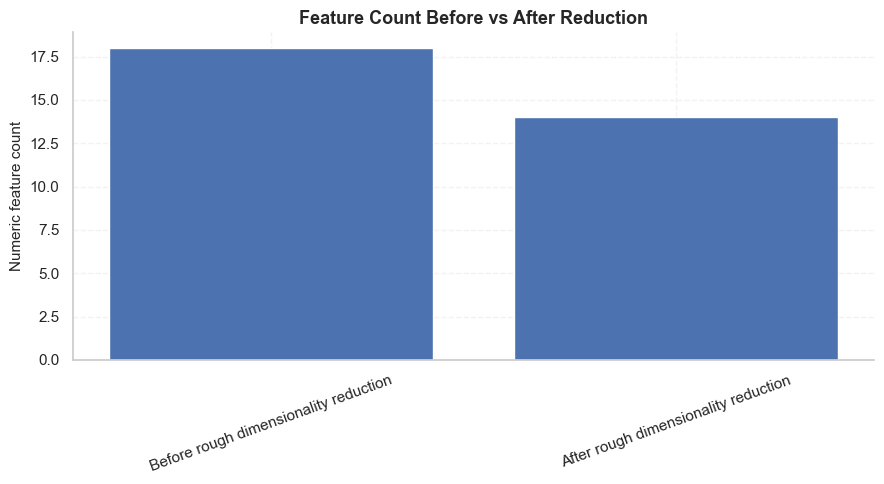

In [25]:
fig, ax = plt.subplots()
ax.bar(comparison["dataset"], comparison["numeric_feature_count"])
ax.set_title("Feature Count Before vs After Reduction")
ax.set_xlabel("")
ax.set_ylabel("Numeric feature count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Interpretation

A good rough dimensionality reduction step usually reduces feature count while preserving most of the useful signal.

Do not expect the quick model metric to be perfect. Use it as a warning signal:
- if performance collapses, the thresholds may be too aggressive
- if performance is stable, the reduced dataset may be a better starting point for modeling

## 14. Business and data-mining interpretation

Rough dimensionality reduction supports better modeling by reducing obvious noise before more expensive steps.

Practical interpretation:
- **Missing-value removal** reduces features that cannot be used reliably.
- **Low-variance removal** removes features that barely change.
- **Correlation removal** reduces redundancy.
- **Target-aware checks** help avoid removing a useful predictor too early.
- **Quick model checks** can warn when thresholds are too aggressive.

In a manufacturing sensor case, this can mean:
- fewer sensors to maintain
- faster preprocessing and imputation
- simpler models
- easier interpretation of quality drivers
- lower risk of overfitting

## 15. Common mistakes and pitfalls

1. **Removing too much too early**  
   Rough dimensionality reduction should be conservative. It is usually safer to remove fewer features at this stage.

2. **Using complete-case analysis aggressively**  
   Dropping every row with one missing value can destroy the dataset.

3. **Choosing thresholds mechanically**  
   Thresholds should be reviewed with histograms, domain logic, and later model evaluation.

4. **Ignoring feature scale in variance analysis**  
   Raw variance is influenced by measurement units.

5. **Blindly trusting correlations**  
   Correlation can be spurious and does not prove causality.

6. **Using Pearson correlation on unsuitable variables**  
   Pearson correlation is intended for metric/numeric variables and linear relationships.

7. **Forgetting operational meaning**  
   A feature may be statistically redundant but easier, cheaper, or more reliable to collect.